# Feature-Level Fusion (Approach b): Concat Autoencoder

**Goal**: replace the raw R-GCN node embedding with the latent code of an autoencoder over `concat(h_graph, h_LLM)`:

$$h_{\text{fused}}(v) = \text{AE}_{\text{enc}}([h_{\text{graph}}(v); h_{\text{LLM}}(v)])$$

**Two phases**:
1. **Phase 1 — Unsupervised AE pretraining.** Reconstruction MSE on the concatenation, computed **only on rows with cached text** (about 11.5K nodes), so the AE does not waste capacity reconstructing zero placeholders for the other nodes without cached text. R-GCN is frozen here.
2. **Phase 2 — Conservative supervised fine-tuning.** Rebuild the training graph after the runtime val split so both val and test diseases are masked from message passing, then start with **scorer-only + AE encoder** fine-tuning at a smaller LR. The AE decoder stays frozen.

Run twice: once with `desc_tier="gpt4o"`, once with `desc_tier="hybrid"`.


## 0. Setup

In [1]:
!pip install -q torch torch-geometric wandb transformers pyyaml matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, sys
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'
PROJECT_ROOT = '/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702'
sys.path.insert(0, PROJECT_ROOT)
%cd {PROJECT_ROOT}

import json
import logging
import numpy as np
import pandas as pd
import torch

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(name)s: %(message)s')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702
Device: cuda


In [4]:
import wandb
WANDB_API_KEY = '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'
key = WANDB_API_KEY.strip()
wandb.login(key=key, relogin=True)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: beatrice-chen (bmi702) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 1. Config

In [ ]:
from pathlib import Path

config = {
    # Data
    'data_dir': 'data/primekg',
    'split_dir': 'data/splits',
    'checkpoint_path': 'data/weights/rgcn_best_model.pt',
    'results_dir': 'results/tables',

    # Text source
    'encoder_name': 'biolinkbert',
    'desc_tier': 'gpt4o',          # change to 'hybrid' for the second run
    'projection': 'nonlinear_ae',
    'embed_dir': 'data/embeddings_256',

    # Dimensions (locked from checkpoint and 256-dim cached embeddings)
    'embed_dim': 256,
    'ae_input_dim': 512,           # concat(h_graph[256], h_llm[256])
    'ae_hidden_dim': 512,
    'latent_dim': 256,             # bottleneck back to scorer's expected dim

    # Phase 1 — AE pretraining
    'ae_pretrain_epochs': 50,
    'ae_pretrain_lr': 1e-3,

    # Phase 2 — conservative supervised fine-tune
    'finetune_epochs': 100,
    'patience': 15,
    'lr': 1e-4,
    'weight_decay': 1e-5,
    'margin': 1.0,
    'neg_ratio': 1,
    'accum_steps': 4,
    'grad_clip': 1.0,
    'batch_size': 512,
    'phase2_train_scope': 'scorer_only',
    'phase2_bypass_fusion': False,
    'val_frac': 0.1,

    'seed': 42,
    'device': 'cuda',
}

for tier in ('gpt4o', 'hybrid'):
    base = Path(config['embed_dir']) / config['encoder_name'] / tier / config['projection']
    for fname in ('drug_embeddings.pt', 'phenotype_embeddings.pt'):
        p = base / fname
        assert p.exists(), f'Missing {p}'
    print(f'✓ tier={tier}: embeddings present')

assert Path(config['checkpoint_path']).exists()


✓ tier=gpt4o: embeddings present
✓ tier=hybrid: embeddings present


## 2. Run experiment — Tier: GPT-4o

In [ ]:
from src.models.feature_fusion_train import run_autoencoder_experiment

config['desc_tier'] = 'gpt4o'
results_gpt4o = run_autoencoder_experiment(config)
print('Test (indication-only) MRR :', results_gpt4o['test_metrics_ind']['MRR'])
print('Test (off-label-aug GT) MRR:', results_gpt4o['test_metrics_off']['MRR'])

run_autoencoder_experiment: start encoder=biolinkbert, tier=gpt4o, projection=nonlinear_ae, device=cuda


/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/data/primekg_loader.py:45: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv(data_dir / "kg.csv")


run_autoencoder_experiment: rebuilt train_graph after runtime val split (heldout_diseases=151, edge_index_shape=(2, 16151876))
run_autoencoder_experiment: loaded baseline checkpoint
run_autoencoder_experiment: built h_llm_full (shape=(129375, 256), text_rows=11475)
run_autoencoder_experiment: fusion module ready (input_dim=512, hidden_dim=512, latent_dim=256)
Phase 1 AE pretraining: start (epochs=50, lr=1.0e-03, n_rows_in_loss=11475)
Phase 1 AE pretraining: epoch 1/50 loss=1.455355
Phase 1 AE pretraining: epoch 11/50 loss=0.772272
Phase 1 AE pretraining: epoch 21/50 loss=0.723543
Phase 1 AE pretraining: epoch 31/50 loss=0.688494
Phase 1 AE pretraining: epoch 41/50 loss=0.656396
Phase 1 AE pretraining: epoch 50/50 loss=0.640059
Phase 1 AE pretraining: finished in 1.1s (final_loss=0.640059)
run_autoencoder_experiment: Phase 1 complete; decoder frozen for Phase 2
Phase 2 setup: train_scope=scorer_only, bypass_fusion=False, trainable_tensors=10, use_amp=True, use_anchoring=False, epochs=10

/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/models/feature_fusion_train.py:852: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Phase 2 setup: cached frozen h_graph once for scorer-only fine-tuning
Phase 2: epoch 1/100 start (best_val_mrr=-1.0000, no_improve=0)
Phase 2: epoch 1/100 done (train_loss=1.0010, val_MRR=0.0116, val_R@10=0.0093, elapsed=21.3s)
Phase 2: new best checkpoint at epoch 1 (val_MRR=0.0116)
Phase 2: epoch 2/100 start (best_val_mrr=0.0116, no_improve=0)
Phase 2: epoch 2/100 done (train_loss=0.9996, val_MRR=0.0203, val_R@10=0.0286, elapsed=21.5s)
Phase 2: new best checkpoint at epoch 2 (val_MRR=0.0203)
Phase 2: epoch 3/100 start (best_val_mrr=0.0203, no_improve=0)
Phase 2: epoch 3/100 done (train_loss=0.9969, val_MRR=0.0234, val_R@10=0.0279, elapsed=21.2s)
Phase 2: new best checkpoint at epoch 3 (val_MRR=0.0234)
Phase 2: epoch 4/100 start (best_val_mrr=0.0234, no_improve=0)
Phase 2: epoch 4/100 done (train_loss=0.9894, val_MRR=0.0232, val_R@10=0.0279, elapsed=21.3s)
Phase 2: epoch 5/100 start (best_val_mrr=0.0234, no_improve=1)
Phase 2: epoch 5/100 done (train_loss=0.9833, val_MRR=0.0231, val_R

ae_pretrain/loss,█▇▅▃▄▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▂▂▃▃▃▄▅▅▅▆▆▆▇▇███▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▆▆▆▆▇
train/loss,██████▇▇▆▅▄▄▃▃▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁
val/MRR,▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▃▃▄▅▇███▇▇█▇█▇▆▆▅▅▅▅▆
val/R@10,▁▃▃▃▃▃▄▄▄▄▄▄▄▁▂▁▃▃▄▄▄▄▄▄▄▄▄▄▆▆▆▆▅██▆▇▇▇▇
ae_pretrain/loss,0.64006
ae_pretrain/n_rows_in_loss,11475
best_val_mrr,0.12373
epoch,40
test_ind/AUPRC,0.03425
test_ind/AUPRC_balanced_micro,0.82065


run_autoencoder_experiment: finished in 973.1s (csv=results/tables/feature_fusion_autoencoder_biolinkbert_gpt4o_nonlinear_ae.csv)
Test (indication-only) MRR : 0.10687947421086809
Test (off-label-aug GT) MRR: 0.12209313133937236


## 3. Run experiment — Tier: Hybrid

In [ ]:
config['desc_tier'] = 'hybrid'
results_hybrid = run_autoencoder_experiment(config)
print('Test (indication-only) MRR :', results_hybrid['test_metrics_ind']['MRR'])
print('Test (off-label-aug GT) MRR:', results_hybrid['test_metrics_off']['MRR'])

run_autoencoder_experiment: start encoder=biolinkbert, tier=hybrid, projection=nonlinear_ae, device=cuda


/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/data/primekg_loader.py:45: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv(data_dir / "kg.csv")


run_autoencoder_experiment: rebuilt train_graph after runtime val split (heldout_diseases=151, edge_index_shape=(2, 16151876))
run_autoencoder_experiment: loaded baseline checkpoint
run_autoencoder_experiment: built h_llm_full (shape=(129375, 256), text_rows=11475)
run_autoencoder_experiment: fusion module ready (input_dim=512, hidden_dim=512, latent_dim=256)
Phase 1 AE pretraining: start (epochs=50, lr=1.0e-03, n_rows_in_loss=11475)
Phase 1 AE pretraining: epoch 1/50 loss=1.465595
Phase 1 AE pretraining: epoch 11/50 loss=0.767204
Phase 1 AE pretraining: epoch 21/50 loss=0.720009
Phase 1 AE pretraining: epoch 31/50 loss=0.686601
Phase 1 AE pretraining: epoch 41/50 loss=0.658113
Phase 1 AE pretraining: epoch 50/50 loss=0.643782
Phase 1 AE pretraining: finished in 0.7s (final_loss=0.643782)
run_autoencoder_experiment: Phase 1 complete; decoder frozen for Phase 2
Phase 2 setup: train_scope=scorer_only, bypass_fusion=False, trainable_tensors=10, use_amp=True, use_anchoring=False, epochs=10

/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/models/feature_fusion_train.py:852: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Phase 2 setup: cached frozen h_graph once for scorer-only fine-tuning
Phase 2: epoch 1/100 start (best_val_mrr=-1.0000, no_improve=0)
Phase 2: epoch 1/100 done (train_loss=1.0002, val_MRR=0.0251, val_R@10=0.0312, elapsed=21.5s)
Phase 2: new best checkpoint at epoch 1 (val_MRR=0.0251)
Phase 2: epoch 2/100 start (best_val_mrr=0.0251, no_improve=0)
Phase 2: epoch 2/100 done (train_loss=0.9988, val_MRR=0.0195, val_R@10=0.0126, elapsed=21.6s)
Phase 2: epoch 3/100 start (best_val_mrr=0.0251, no_improve=1)
Phase 2: epoch 3/100 done (train_loss=0.9980, val_MRR=0.0189, val_R@10=0.0086, elapsed=21.2s)
Phase 2: epoch 4/100 start (best_val_mrr=0.0251, no_improve=2)
Phase 2: epoch 4/100 done (train_loss=0.9926, val_MRR=0.0242, val_R@10=0.0077, elapsed=21.3s)
Phase 2: epoch 5/100 start (best_val_mrr=0.0251, no_improve=3)
Phase 2: epoch 5/100 done (train_loss=0.9820, val_MRR=0.0274, val_R@10=0.0117, elapsed=21.1s)
Phase 2: new best checkpoint at epoch 5 (val_MRR=0.0274)
Phase 2: epoch 6/100 start (be

ae_pretrain/loss,█▇▆▄▄▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▂▂▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▇▇███▁▁▂▂▂▂▃▄▄▄▅▅▆▆▆▇
train/loss,██████▇▇▅▄▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁
val/MRR,▁▁▁▁▂▂▂▂▄▄▇▇▇▇▇▇▇▇▇█████████████▆▆▆▆▆▆▇▅
val/R@10,▃▁▁▁▁▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▄▄▄▆█▇▇▇▇▇▇█▇▇▇▇▇██
ae_pretrain/loss,0.64378
ae_pretrain/n_rows_in_loss,11475
best_val_mrr,0.1316
epoch,44
test_ind/AUPRC,0.04899
test_ind/AUPRC_balanced_micro,0.8167


run_autoencoder_experiment: finished in 1084.5s (csv=results/tables/feature_fusion_autoencoder_biolinkbert_hybrid_nonlinear_ae.csv)
Test (indication-only) MRR : 0.11107769773653786
Test (off-label-aug GT) MRR: 0.12336079365690554


## 4. AE reconstruction-loss curve

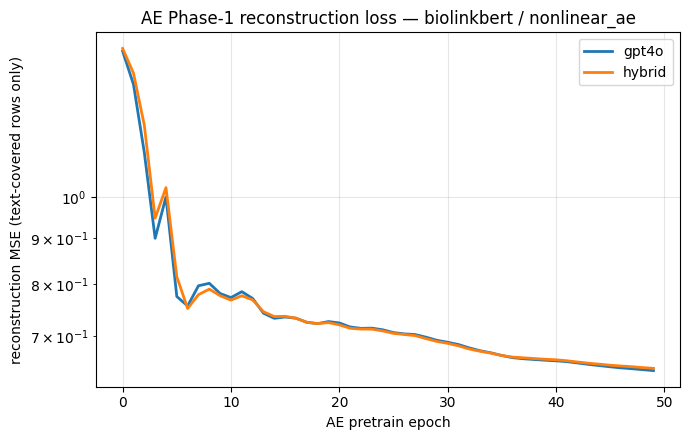

Saved results/figures/ae_reconstruction_loss.png


In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

FIGURES_DIR = Path('results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(results_gpt4o['ae_pretrain_losses'], label='gpt4o', linewidth=2)
ax.plot(results_hybrid['ae_pretrain_losses'], label='hybrid', linewidth=2)
ax.set_xlabel('AE pretrain epoch')
ax.set_ylabel('reconstruction MSE (text-covered rows only)')
ax.set_title('AE Phase-1 reconstruction loss — biolinkbert / nonlinear_ae')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
out = FIGURES_DIR / 'ae_reconstruction_loss.png'
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved {out}')

## 5. gpt4o vs hybrid comparison

In [ ]:
import json
import re
from pathlib import Path
import pandas as pd

METRIC_KEYS = [
    'MRR', 'R@1', 'R@5', 'R@10', 'R@50',
    'AUROC', 'AUPRC',
    'AUROC_balanced_micro', 'AUPRC_balanced_micro',
    'MRR_seen_all', 'MRR_seen_some', 'MRR_seen_none',
]

def _extract_config_value(text, key):
    match = re.search(rf'{re.escape(key)}:\n\s+value:\s+(.+)', text)
    return match.group(1).strip() if match else None

def _find_wandb_summary(desc_tier, projection='nonlinear_ae', fusion_variant='ae'):
    wandb_root = Path('wandb')
    candidates = []
    for config_path in wandb_root.glob('run-*/files/config.yaml'):
        try:
            config_text = config_path.read_text()
        except FileNotFoundError:
            continue
        if _extract_config_value(config_text, 'desc_tier') != desc_tier:
            continue
        if _extract_config_value(config_text, 'projection') != projection:
            continue
        summary_path = config_path.with_name('wandb-summary.json')
        if not summary_path.exists():
            continue
        summary = json.loads(summary_path.read_text())
        summary_variant = summary.get('fusion_variant')
        if fusion_variant == 'residual_ae':
            if summary_variant != 'residual_ae':
                continue
        else:
            if summary_variant not in (None, 'ae'):
                continue
        if 'test_ind/MRR' not in summary:
            continue
        candidates.append(summary_path)
    if not candidates:
        raise FileNotFoundError(f'No wandb-summary.json found for tier={desc_tier}, projection={projection}, fusion_variant={fusion_variant}')
    return max(candidates, key=lambda p: p.stat().st_mtime)

def _load_saved_result(desc_tier, csv_name, fusion_variant='ae', projection='nonlinear_ae'):
    summary = json.loads(_find_wandb_summary(desc_tier, projection=projection, fusion_variant=fusion_variant).read_text())
    csv_path = Path('results/tables') / csv_name
    result = {
        'test_metrics_ind': {k: summary.get(f'test_ind/{k}', float('nan')) for k in METRIC_KEYS},
        'test_metrics_off': {k: summary.get(f'test_off/{k}', float('nan')) for k in METRIC_KEYS},
        'best_val_mrr': summary.get('best_val_mrr', float('nan')),
        'best_epoch': summary.get('best_epoch'),
        'fusion_variant': summary.get('fusion_variant', fusion_variant),
        'csv_path': str(csv_path),
    }
    if csv_path.exists():
        result['per_disease_df'] = pd.read_csv(csv_path)
    return result

if 'results_gpt4o' not in globals():
    results_gpt4o = _load_saved_result(
        desc_tier='gpt4o',
        csv_name='feature_fusion_autoencoder_biolinkbert_gpt4o_nonlinear_ae.csv',
        fusion_variant='ae',
    )
if 'results_hybrid' not in globals():
    results_hybrid = _load_saved_result(
        desc_tier='hybrid',
        csv_name='feature_fusion_autoencoder_biolinkbert_hybrid_nonlinear_ae.csv',
        fusion_variant='ae',
    )

def metrics_row(tier, gt, m):
    return {'tier': tier, 'gt': gt, **{k: m.get(k, float('nan')) for k in METRIC_KEYS}}

summary = pd.DataFrame([
    metrics_row('gpt4o',  'indication', results_gpt4o['test_metrics_ind']),
    metrics_row('gpt4o',  'off-label',  results_gpt4o['test_metrics_off']),
    metrics_row('hybrid', 'indication', results_hybrid['test_metrics_ind']),
    metrics_row('hybrid', 'off-label',  results_hybrid['test_metrics_off']),
]).set_index(['tier', 'gt'])
summary.round(4)


MRR     R@1     R@5    R@10    R@50   AUROC   AUPRC  \
tier   gt                                                                   
gpt4o  indication  0.1069  0.0080  0.0198  0.0292  0.0722  0.8513  0.0342   
       off-label   0.1221  0.0081  0.0212  0.0307  0.0786  0.8553  0.0370   
hybrid indication  0.1111  0.0077  0.0339  0.0439  0.0653  0.8496  0.0490   
       off-label   0.1234  0.0073  0.0317  0.0412  0.0697  0.8533  0.0483   

                   AUROC_balanced_micro  AUPRC_balanced_micro  MRR_seen_all  \
tier   gt                                                                     
gpt4o  indication                0.8661                0.8206        0.1070   
       off-label                 0.8853                0.8467        0.1044   
hybrid indication                0.8615                0.8167        0.1038   
       off-label                 0.8841                0.8663        0.0841   

                   MRR_seen_some  MRR_seen_none  
tier   gt                                        
gpt4o  indication         0.1419         0.0043  
       off-label          0.1682         0.0004  
hybrid indication         0.1631         0.0024  
       off-label          0.1982         0.0004

In [ ]:
from pathlib import Path
import json

OUT = Path("results/tables/feature_fusion_autoencoder_metrics.json")

payload = {
    "ae_gpt4o": {
        "test_metrics_ind": results_gpt4o["test_metrics_ind"],
        "test_metrics_off": results_gpt4o["test_metrics_off"],
        "best_val_mrr": results_gpt4o["best_val_mrr"],
        "best_epoch": results_gpt4o.get("best_epoch"),
        "csv_path": results_gpt4o["csv_path"],
    },
    "ae_hybrid": {
        "test_metrics_ind": results_hybrid["test_metrics_ind"],
        "test_metrics_off": results_hybrid["test_metrics_off"],
        "best_val_mrr": results_hybrid["best_val_mrr"],
        "best_epoch": results_hybrid.get("best_epoch"),
        "csv_path": results_hybrid["csv_path"],
    },
}

OUT.write_text(json.dumps(payload, indent=2))
print(f"Saved {OUT}")

Saved results/tables/feature_fusion_autoencoder_metrics.json


## 6. Residual Autoencoder — Tier: GPT-4o

Residual feature fusion keeps the graph embedding as the base representation and learns an additive correction:

$$h_{\text{fused}}(v) = h_{\text{graph}}(v) + f([h_{\text{graph}}(v); h_{\text{LLM}}(v)])$$


In [ ]:
from src.models.feature_fusion_train import run_residual_autoencoder_experiment

config['desc_tier'] = 'gpt4o'
results_residual_gpt4o = run_residual_autoencoder_experiment(config)
print('Residual AE Test (indication-only) MRR :', results_residual_gpt4o['test_metrics_ind']['MRR'])
print('Residual AE Test (off-label-aug GT) MRR:', results_residual_gpt4o['test_metrics_off']['MRR'])

_run_autoencoder_family_experiment: start variant=residual_ae, encoder=biolinkbert, tier=gpt4o, projection=nonlinear_ae, device=cuda


/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/data/primekg_loader.py:45: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv(data_dir / "kg.csv")


_run_autoencoder_family_experiment: rebuilt train_graph after runtime val split (heldout_diseases=151, edge_index_shape=(2, 16151876))
_run_autoencoder_family_experiment: loaded baseline checkpoint
_run_autoencoder_family_experiment: built h_llm_full (shape=(129375, 256), text_rows=11475)
_run_autoencoder_family_experiment: fusion module ready (variant=residual_ae, input_dim=512, hidden_dim=512, latent_dim=256)
Phase 1 AE pretraining: start (epochs=50, lr=1.0e-03, n_rows_in_loss=11475)
Phase 1 AE pretraining: epoch 1/50 loss=1.469293
Phase 1 AE pretraining: epoch 11/50 loss=0.775216
Phase 1 AE pretraining: epoch 21/50 loss=0.723162
Phase 1 AE pretraining: epoch 31/50 loss=0.688001
Phase 1 AE pretraining: epoch 41/50 loss=0.657353
Phase 1 AE pretraining: epoch 50/50 loss=0.643371
Phase 1 AE pretraining: finished in 1.1s (final_loss=0.643371)
_run_autoencoder_family_experiment: Phase 1 complete; decoder frozen for Phase 2
Phase 2 setup: train_scope=scorer_only, bypass_fusion=False, train

/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/models/feature_fusion_train.py:849: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Phase 2 setup: cached frozen h_graph once for scorer-only fine-tuning
Phase 2: epoch 1/100 start (best_val_mrr=-1.0000, no_improve=0)
Phase 2: epoch 1/100 done (train_loss=0.0679, val_MRR=0.6493, val_R@10=0.7412, elapsed=21.8s)
Phase 2: new best checkpoint at epoch 1 (val_MRR=0.6493)
Phase 2: epoch 2/100 start (best_val_mrr=0.6493, no_improve=0)
Phase 2: epoch 2/100 done (train_loss=0.0673, val_MRR=0.6687, val_R@10=0.7412, elapsed=22.3s)
Phase 2: new best checkpoint at epoch 2 (val_MRR=0.6687)
Phase 2: epoch 3/100 start (best_val_mrr=0.6687, no_improve=0)
Phase 2: epoch 3/100 done (train_loss=0.0673, val_MRR=0.6707, val_R@10=0.7453, elapsed=21.7s)
Phase 2: new best checkpoint at epoch 3 (val_MRR=0.6707)
Phase 2: epoch 4/100 start (best_val_mrr=0.6707, no_improve=0)
Phase 2: epoch 4/100 done (train_loss=0.0665, val_MRR=0.6727, val_R@10=0.7398, elapsed=22.0s)
Phase 2: new best checkpoint at epoch 4 (val_MRR=0.6727)
Phase 2: epoch 5/100 start (best_val_mrr=0.6727, no_improve=0)
Phase 2: e

ae_pretrain/loss,█▇▆▃▄▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▂▂▃▃▃▃▄▄▅▆▆▆▆▆▇▁▂▂▂▂▃▃▃▄▄▅▅▅▅▆▆▆▇▇▇▇█
train/loss,█▇▆▆▆█▇▂▆▇▃▁▃▄▅▃▆▆▅▁▆▂▅▅▃▃▇▂▁▂▅▅▄▅▃▆█▆▃▄
val/MRR,▁▂▃▂▂▃▃▃▃▄▆▆▆▆▆▅▆▆▆▆▆▇▇▇▆▇▇▇▆▆██▆▆▆▅▆▆▆▆
val/R@10,▁▁▁▁▃▄▃▃▃▂▂▃▄▄▄▄▄▄▄▄▄▄▅▅▅▅▇▆▆▇▆▆▄███▇▇▇▆
ae_pretrain/loss,0.64337
ae_pretrain/n_rows_in_loss,11475
best_val_mrr,0.7398
epoch,63
fusion_variant,residual_ae
test_ind/AUPRC,0.14597


_run_autoencoder_family_experiment: finished in 1522.8s (csv=results/tables/feature_fusion_residual_autoencoder_biolinkbert_gpt4o_nonlinear_ae.csv)
Residual AE Test (indication-only) MRR : 0.17325233835307471
Residual AE Test (off-label-aug GT) MRR: 0.23347916800392302


## 7. Residual Autoencoder — Tier: Hybrid


In [ ]:
config['desc_tier'] = 'hybrid'
results_residual_hybrid = run_residual_autoencoder_experiment(config)
print('Residual AE Test (indication-only) MRR :', results_residual_hybrid['test_metrics_ind']['MRR'])
print('Residual AE Test (off-label-aug GT) MRR:', results_residual_hybrid['test_metrics_off']['MRR'])

_run_autoencoder_family_experiment: start variant=residual_ae, encoder=biolinkbert, tier=hybrid, projection=nonlinear_ae, device=cuda


/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/data/primekg_loader.py:45: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv(data_dir / "kg.csv")


_run_autoencoder_family_experiment: rebuilt train_graph after runtime val split (heldout_diseases=151, edge_index_shape=(2, 16151876))
_run_autoencoder_family_experiment: loaded baseline checkpoint
_run_autoencoder_family_experiment: built h_llm_full (shape=(129375, 256), text_rows=11475)
_run_autoencoder_family_experiment: fusion module ready (variant=residual_ae, input_dim=512, hidden_dim=512, latent_dim=256)
Phase 1 AE pretraining: start (epochs=50, lr=1.0e-03, n_rows_in_loss=11475)
Phase 1 AE pretraining: epoch 1/50 loss=1.452274
Phase 1 AE pretraining: epoch 11/50 loss=0.770883
Phase 1 AE pretraining: epoch 21/50 loss=0.719983
Phase 1 AE pretraining: epoch 31/50 loss=0.680408
Phase 1 AE pretraining: epoch 41/50 loss=0.656319
Phase 1 AE pretraining: epoch 50/50 loss=0.643425
Phase 1 AE pretraining: finished in 0.8s (final_loss=0.643425)
_run_autoencoder_family_experiment: Phase 1 complete; decoder frozen for Phase 2
Phase 2 setup: train_scope=scorer_only, bypass_fusion=False, train

/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/models/feature_fusion_train.py:849: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Phase 2 setup: cached frozen h_graph once for scorer-only fine-tuning
Phase 2: epoch 1/100 start (best_val_mrr=-1.0000, no_improve=0)
Phase 2: epoch 1/100 done (train_loss=0.0693, val_MRR=0.6624, val_R@10=0.7357, elapsed=21.7s)
Phase 2: new best checkpoint at epoch 1 (val_MRR=0.6624)
Phase 2: epoch 2/100 start (best_val_mrr=0.6624, no_improve=0)
Phase 2: epoch 2/100 done (train_loss=0.0669, val_MRR=0.6744, val_R@10=0.7320, elapsed=22.2s)
Phase 2: new best checkpoint at epoch 2 (val_MRR=0.6744)
Phase 2: epoch 3/100 start (best_val_mrr=0.6744, no_improve=0)
Phase 2: epoch 3/100 done (train_loss=0.0656, val_MRR=0.6789, val_R@10=0.7552, elapsed=21.8s)
Phase 2: new best checkpoint at epoch 3 (val_MRR=0.6789)
Phase 2: epoch 4/100 start (best_val_mrr=0.6789, no_improve=0)
Phase 2: epoch 4/100 done (train_loss=0.0648, val_MRR=0.6902, val_R@10=0.7531, elapsed=22.0s)
Phase 2: new best checkpoint at epoch 4 (val_MRR=0.6902)
Phase 2: epoch 5/100 start (best_val_mrr=0.6902, no_improve=0)
Phase 2: e

ae_pretrain/loss,█▇▅▃▄▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▅▆▆▇███▁▂▂▃▃▃▃▃▄▄▆▆▆▇▇▇▇███
train/loss,█▆▅▄▅▅▄▄▅▅▁▆▃▃▃▄▇▄▁▃▄▃▄▆▅▅▃▅▅▃▂▄▁▂█▇▄▆▄▃
val/MRR,▁▂▃▄▄▄▄▅▄▂▂▃▃▃▄▄▄▄▄▄▅▅▆▆▇█████▇▇▆▆▆▆▆▆▆▆
val/R@10,▂▁▇▆▆▆▆▇▇██▆▅▅▅▄▄▄▆▆▇▇▇▇▇▇▇██████▆▆▆▆▆▆▆
ae_pretrain/loss,0.64342
ae_pretrain/n_rows_in_loss,11475
best_val_mrr,0.7357
epoch,44
fusion_variant,residual_ae
test_ind/AUPRC,0.14439


_run_autoencoder_family_experiment: finished in 1089.9s (csv=results/tables/feature_fusion_residual_autoencoder_biolinkbert_hybrid_nonlinear_ae.csv)
Residual AE Test (indication-only) MRR : 0.1996716522873125
Residual AE Test (off-label-aug GT) MRR: 0.2523763743103832


## 8. AE vs Residual AE Comparison


In [5]:
import json
import re
from pathlib import Path
import pandas as pd

if 'METRIC_KEYS' not in globals():
    METRIC_KEYS = [
        'MRR', 'R@1', 'R@5', 'R@10', 'R@50',
        'AUROC', 'AUPRC',
        'AUROC_balanced_micro', 'AUPRC_balanced_micro',
        'MRR_seen_all', 'MRR_seen_some', 'MRR_seen_none',
    ]

def _extract_config_value(text, key):
    match = re.search(rf'{re.escape(key)}:\n\s+value:\s+(.+)', text)
    return match.group(1).strip() if match else None

def _find_wandb_summary(desc_tier, projection='nonlinear_ae', fusion_variant='ae'):
    wandb_root = Path('wandb')
    candidates = []
    for config_path in wandb_root.glob('run-*/files/config.yaml'):
        try:
            config_text = config_path.read_text()
        except FileNotFoundError:
            continue
        if _extract_config_value(config_text, 'desc_tier') != desc_tier:
            continue
        if _extract_config_value(config_text, 'projection') != projection:
            continue
        summary_path = config_path.with_name('wandb-summary.json')
        if not summary_path.exists():
            continue
        summary = json.loads(summary_path.read_text())
        summary_variant = summary.get('fusion_variant')
        if fusion_variant == 'residual_ae':
            if summary_variant != 'residual_ae':
                continue
        else:
            if summary_variant not in (None, 'ae'):
                continue
        if 'test_ind/MRR' not in summary:
            continue
        candidates.append(summary_path)
    if not candidates:
        raise FileNotFoundError(f'No wandb-summary.json found for tier={desc_tier}, projection={projection}, fusion_variant={fusion_variant}')
    return max(candidates, key=lambda p: p.stat().st_mtime)

def _load_saved_result(desc_tier, csv_name, fusion_variant='ae', projection='nonlinear_ae'):
    summary = json.loads(_find_wandb_summary(desc_tier, projection=projection, fusion_variant=fusion_variant).read_text())
    csv_path = Path('results/tables') / csv_name
    result = {
        'test_metrics_ind': {k: summary.get(f'test_ind/{k}', float('nan')) for k in METRIC_KEYS},
        'test_metrics_off': {k: summary.get(f'test_off/{k}', float('nan')) for k in METRIC_KEYS},
        'best_val_mrr': summary.get('best_val_mrr', float('nan')),
        'best_epoch': summary.get('best_epoch'),
        'fusion_variant': summary.get('fusion_variant', fusion_variant),
        'csv_path': str(csv_path),
    }
    if csv_path.exists():
        result['per_disease_df'] = pd.read_csv(csv_path)
    return result

RESULT_SPECS = {
    'results_gpt4o': {
        'desc_tier': 'gpt4o',
        'fusion_variant': 'ae',
        'csv_name': 'feature_fusion_autoencoder_biolinkbert_gpt4o_nonlinear_ae.csv',
    },
    'results_hybrid': {
        'desc_tier': 'hybrid',
        'fusion_variant': 'ae',
        'csv_name': 'feature_fusion_autoencoder_biolinkbert_hybrid_nonlinear_ae.csv',
    },
    'results_residual_gpt4o': {
        'desc_tier': 'gpt4o',
        'fusion_variant': 'residual_ae',
        'csv_name': 'feature_fusion_residual_autoencoder_biolinkbert_gpt4o_nonlinear_ae.csv',
    },
    'results_residual_hybrid': {
        'desc_tier': 'hybrid',
        'fusion_variant': 'residual_ae',
        'csv_name': 'feature_fusion_residual_autoencoder_biolinkbert_hybrid_nonlinear_ae.csv',
    },
}

for var_name, spec in RESULT_SPECS.items():
    if var_name in globals():
        continue
    try:
        globals()[var_name] = _load_saved_result(**spec)
    except FileNotFoundError:
        pass

comparison_rows = []
for variant, tier, var_name in [
    ('ae', 'gpt4o', 'results_gpt4o'),
    ('ae', 'hybrid', 'results_hybrid'),
    ('residual_ae', 'gpt4o', 'results_residual_gpt4o'),
    ('residual_ae', 'hybrid', 'results_residual_hybrid'),
]:
    if var_name not in globals():
        continue
    result = globals()[var_name]
    comparison_rows.append({'variant': variant, 'tier': tier, 'gt': 'indication', **{k: result['test_metrics_ind'].get(k, float('nan')) for k in METRIC_KEYS}})
    comparison_rows.append({'variant': variant, 'tier': tier, 'gt': 'off-label', **{k: result['test_metrics_off'].get(k, float('nan')) for k in METRIC_KEYS}})

if not comparison_rows:
    raise FileNotFoundError('No saved feature-fusion results found in memory or on disk.')

comparison_all = pd.DataFrame(comparison_rows).set_index(['variant', 'tier', 'gt'])
display(comparison_all.round(4))

compare_focus_rows = []
for tier, ae_var, residual_var in [
    ('gpt4o', 'results_gpt4o', 'results_residual_gpt4o'),
    ('hybrid', 'results_hybrid', 'results_residual_hybrid'),
]:
    if ae_var not in globals() or residual_var not in globals():
        continue
    for gt, key in [('indication', 'test_metrics_ind'), ('off-label', 'test_metrics_off')]:
        ae_res = globals()[ae_var][key]
        residual_res = globals()[residual_var][key]
        compare_focus_rows.append({
            'tier': tier,
            'gt': gt,
            'MRR_ae': ae_res['MRR'],
            'MRR_residual_ae': residual_res['MRR'],
            'dMRR': residual_res['MRR'] - ae_res['MRR'],
            'R10_ae': ae_res['R@10'],
            'R10_residual_ae': residual_res['R@10'],
            'dR10': residual_res['R@10'] - ae_res['R@10'],
        })

if compare_focus_rows:
    compare_focus = pd.DataFrame(compare_focus_rows).set_index(['tier', 'gt'])
    compare_focus.round(4)
else:
    print('Residual AE saved results not found yet; showing only available variants above.')


MRR     R@1     R@5    R@10    R@50   AUROC  \
variant     tier   gt                                                           
ae          gpt4o  indication  0.1805  0.0398  0.1289  0.1723  0.3395  0.8590   
                   off-label   0.2223  0.0426  0.1297  0.1822  0.3636  0.8600   
            hybrid indication  0.1818  0.0439  0.1368  0.1800  0.3441  0.8479   
                   off-label   0.2494  0.0494  0.1391  0.1949  0.3627  0.8495   
residual_ae gpt4o  indication  0.1733  0.0362  0.1378  0.1859  0.3386  0.8511   
                   off-label   0.2335  0.0413  0.1383  0.1883  0.3611  0.8524   
            hybrid indication  0.1997  0.0501  0.1241  0.1648  0.3403  0.8461   
                   off-label   0.2524  0.0541  0.1255  0.1758  0.3628  0.8476   

                                AUPRC  AUROC_balanced_micro  \
variant     tier   gt                                         
ae          gpt4o  indication  0.1470                0.7870   
                   off-label   0.1620                0.8026   
            hybrid indication  0.1501                0.7821   
                   off-label   0.1685                0.7960   
residual_ae gpt4o  indication  0.1460                0.7781   
                   off-label   0.1630                0.7918   
            hybrid indication  0.1444                0.7663   
                   off-label   0.1601                0.7806   

                               AUPRC_balanced_micro  MRR_seen_all  \
variant     tier   gt                                               
ae          gpt4o  indication                0.7664        0.2263   
                   off-label                 0.7793        0.2382   
            hybrid indication                0.7611        0.2106   
                   off-label                 0.7727        0.2396   
residual_ae gpt4o  indication                0.7580        0.2170   
                   off-label                 0.7720        0.2331   
            hybrid indication                0.7336        0.2178   
                   off-label                 0.7461        0.2336   

                               MRR_seen_some  MRR_seen_none  
variant     tier   gt                                        
ae          gpt4o  indication         0.1389         0.0314  
                   off-label          0.2427         0.0005  
            hybrid indication         0.1752         0.0308  
                   off-label          0.3087         0.0005  
residual_ae gpt4o  indication         0.1331         0.0315  
                   off-label          0.2773         0.0006  
            hybrid indication         0.2207         0.0314  
                   off-label          0.3241         0.0005